In [ ]:
# -*- coding: utf-8 -*-

In [ ]:
# jupyter:

#   jupytext:

#     text_representation:

#       extension: .py

#       format_name: light

#       format_version: '1.5'

#       jupytext_version: 1.14.0

#   kernelspec:

#     display_name: Python 3 (ipykernel)

#     language: python

#     name: python3

# Exploration du jeu de données Tweets (Sentiment Analysis)


Objectifs :

* Charger les données

* Analyser la distribution des sentiments

* Examiner les longueurs de texte et de texte sélectionné

* Visualiser les mots fréquents

In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

import re

from wordcloud import WordCloud, STOPWORDS



# Configuration pour les plots

sns.set_style('whitegrid')

plt.rcParams['figure.figsize'] = (10, 6)

## 1. Chargement des données


On charge le fichier `tweet.csv` depuis le dossier `data`.

In [2]:
# Chemin relatif depuis le dossier 'notebooks/' vers 'data/'

DATA_PATH = '../data/tweet.csv'



try:

    df = pd.read_csv(DATA_PATH, encoding='ISO-8859-1') # Essayer avec cet encodage si utf-8 échoue

    print(f"Données chargées depuis : {DATA_PATH}")

    print(f"Shape initiale : {df.shape}")

except FileNotFoundError:

    print(f"ERREUR : Fichier non trouvé à '{DATA_PATH}'. Assurez-vous que le fichier est bien là.")

    df = None

except Exception as e:

    print(f"ERREUR lors du chargement : {e}")

    df = None

Données chargées depuis : ../data/tweet.csv
Shape initiale : (27481, 4)


In [3]:
if df is not None:

    print("\n--- Informations générales ---")

    df.info()



    print("\n--- Aperçu des données ---")

    display(df.head())



    print("\n--- Statistiques descriptives (numériques) ---")

    # display(df.describe()) # Peu utile ici car pas de colonnes numériques intéressantes



    print("\n--- Vérification des valeurs manquantes ---")

    display(df.isnull().sum())


--- Informations générales ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB

--- Aperçu des données ---


,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative



--- Statistiques descriptives (numériques) ---

--- Vérification des valeurs manquantes ---


textID           0
text             1
selected_text    1
sentiment        0
dtype: int64

## 2. Nettoyage Initial


On supprime les lignes où `text` ou `sentiment` sont manquants et on vérifie que les sentiments sont corrects.

In [4]:
if df is not None:

    initial_rows = len(df)

    df.dropna(subset=['text', 'sentiment'], inplace=True)

    # Garder seulement les sentiments valides

    valid_sentiments = ['positive', 'negative', 'neutral']

    df = df[df['sentiment'].isin(valid_sentiments)]

    df = df.reset_index(drop=True)

    print(f"Shape après nettoyage : {df.shape}")

    print(f"{initial_rows - len(df)} lignes supprimées.")

Shape après nettoyage : (27480, 4)
1 lignes supprimées.


## 3. Analyse du Sentiment


Distribution des classes de sentiment.


--- Distribution des Sentiments ---
sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64


C:\Users\dadzo\AppData\Local\Temp\ipykernel_6172\544688315.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', order=sentiment_counts.index, palette='viridis')


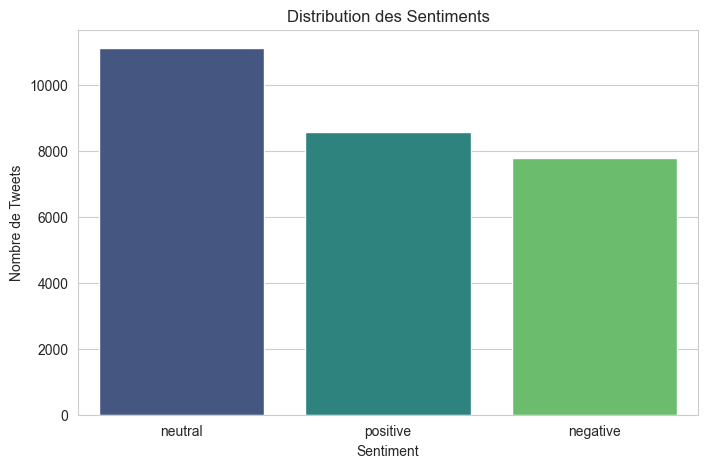

In [6]:
if df is not None:

    print("\n--- Distribution des Sentiments ---")

    sentiment_counts = df['sentiment'].value_counts()

    print(sentiment_counts)



    # Visualisation

    plt.figure(figsize=(8, 5))

    sns.countplot(data=df, x='sentiment', order=sentiment_counts.index, palette='viridis')

    plt.title('Distribution des Sentiments')

    plt.xlabel('Sentiment')

    plt.ylabel('Nombre de Tweets')

    plt.show()

## 4. Analyse des Textes


On regarde la longueur des colonnes `text` et `selected_text`.


--- Statistiques sur les longueurs ---


,text_len,selected_text_len,text_word_count,selected_text_word_count
count,27480.000000,27480.000000,27480.000000,27480.000000
mean,68.354949,36.719469,12.902875,7.102511
std,35.624417,35.681588,6.925938,6.891179
min,3.000000,1.000000,1.000000,1.000000
25%,39.000000,8.000000,7.000000,1.000000
50%,64.000000,22.000000,12.000000,4.000000
75%,97.000000,55.000000,18.000000,11.000000
max,159.000000,158.000000,33.000000,33.000000


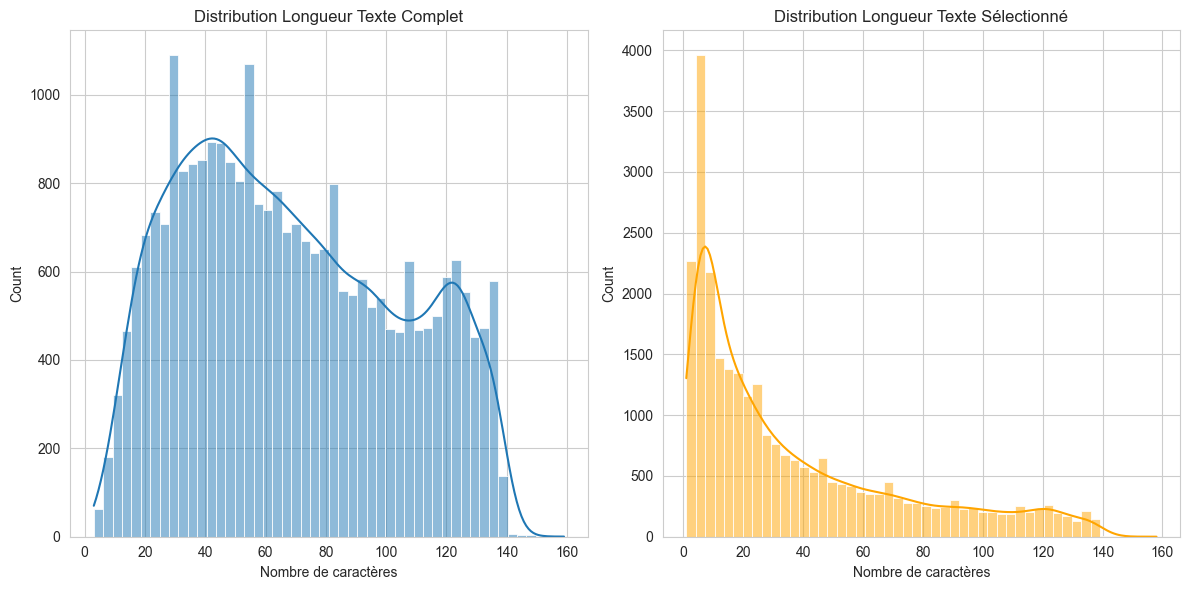

C:\Users\dadzo\AppData\Local\Temp\ipykernel_6172\3857380850.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentiment', y='text_len', palette='viridis')


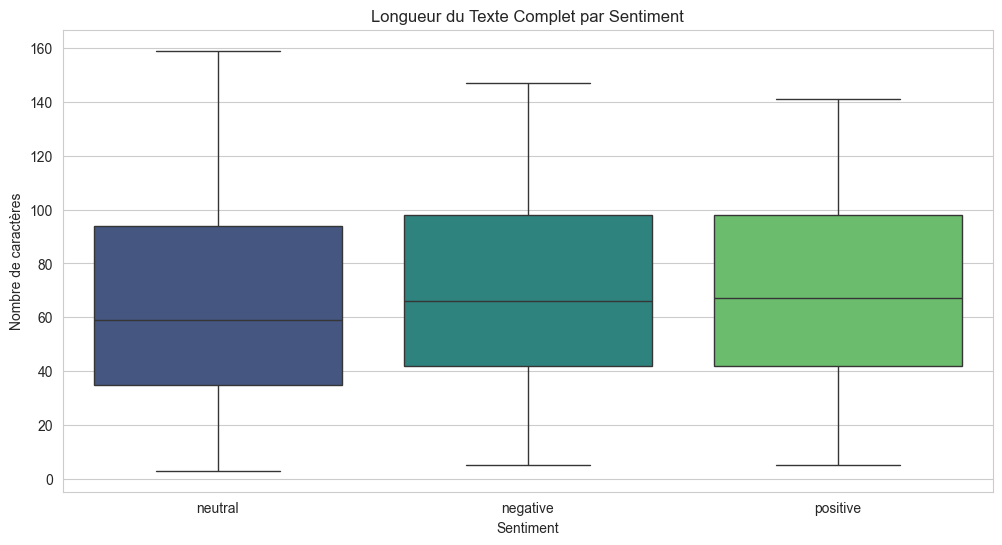

C:\Users\dadzo\AppData\Local\Temp\ipykernel_6172\3857380850.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentiment', y='selected_text_len', palette='viridis')


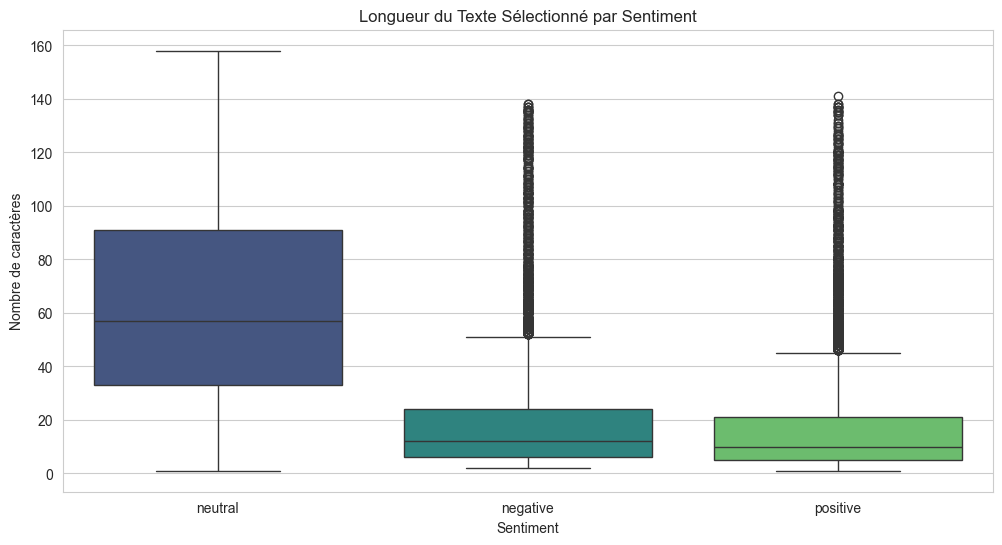

In [8]:
if df is not None:

    # Calcul des longueurs

    df['text_len'] = df['text'].astype(str).apply(len)

    df['selected_text_len'] = df['selected_text'].astype(str).apply(len)

    df['text_word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

    df['selected_text_word_count'] = df['selected_text'].astype(str).apply(lambda x: len(x.split()))



    print("\n--- Statistiques sur les longueurs ---")

    display(df[['text_len', 'selected_text_len', 'text_word_count', 'selected_text_word_count']].describe())



    # Visualisation des longueurs de texte

    plt.figure(figsize=(12, 6))



    plt.subplot(1, 2, 1)

    sns.histplot(df['text_len'], bins=50, kde=True)

    plt.title('Distribution Longueur Texte Complet')

    plt.xlabel('Nombre de caractères')



    plt.subplot(1, 2, 2)

    sns.histplot(df['selected_text_len'], bins=50, kde=True, color='orange')

    plt.title('Distribution Longueur Texte Sélectionné')

    plt.xlabel('Nombre de caractères')



    plt.tight_layout()

    plt.show()



    # Visualisation des longueurs de texte par sentiment

    plt.figure(figsize=(12, 6))

    sns.boxplot(data=df, x='sentiment', y='text_len', palette='viridis')

    plt.title('Longueur du Texte Complet par Sentiment')

    plt.xlabel('Sentiment')

    plt.ylabel('Nombre de caractères')

    plt.show()



    plt.figure(figsize=(12, 6))

    sns.boxplot(data=df, x='sentiment', y='selected_text_len', palette='viridis')

    plt.title('Longueur du Texte Sélectionné par Sentiment')

    plt.xlabel('Sentiment')

    plt.ylabel('Nombre de caractères')

    plt.show()

### Relation entre `text` et `selected_text`

In [9]:
if df is not None:

    # Pourcentage de cas où selected_text == text

    same_text_percentage = (df['text'] == df['selected_text']).mean() * 100

    print(f"\nPourcentage de cas où 'selected_text' == 'text' : {same_text_percentage:.2f}%")



    # Particulièrement pour le sentiment 'neutral'

    neutral_df = df[df['sentiment'] == 'neutral']

    if not neutral_df.empty:

         neutral_same_percentage = (neutral_df['text'] == neutral_df['selected_text']).mean() * 100

         print(f"Pourcentage pour les tweets 'neutral' : {neutral_same_percentage:.2f}%")

    else:

        print("Aucun tweet 'neutral' trouvé après nettoyage.")


Pourcentage de cas où 'selected_text' == 'text' : 26.50%
Pourcentage pour les tweets 'neutral' : 53.34%


## 5. Nettoyage de Texte & Word Clouds


On nettoie le texte pour visualiser les mots les plus fréquents par sentiment.

In [10]:
# Fonction de nettoyage (similaire à celle de vos scripts)

def clean_text_for_wc(text):

    if not isinstance(text, str):

        return ""

    text = text.lower()

    text = re.sub(r'http\S+|www\S+', '', text) # Remove URLs

    text = re.sub(r'@\w+|#\w+', '', text) # Remove mentions and hashtags symbols but keep the word

    text = re.sub(r'[^a-z\s]', '', text) # Keep only letters and spaces

    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces

    # On pourrait ajouter la suppression des stopwords ici

    return text



if df is not None:

    print("Nettoyage du texte pour les Word Clouds...")

    df['cleaned_text'] = df['text'].apply(clean_text_for_wc)

    print("Nettoyage terminé.")

    display(df[['text', 'cleaned_text']].head())

Nettoyage du texte pour les Word Clouds...
Nettoyage terminé.


,text,cleaned_text
0,"I`d have responded, if I were going",id have responded if i were going
1,Sooo SAD I will miss you here in San Diego!!!,sooo sad i will miss you here in san diego
2,my boss is bullying me...,my boss is bullying me
3,what interview! leave me alone,what interview leave me alone
4,"Sons of ****, why couldn`t they put them on t...",sons of why couldnt they put them on the relea...


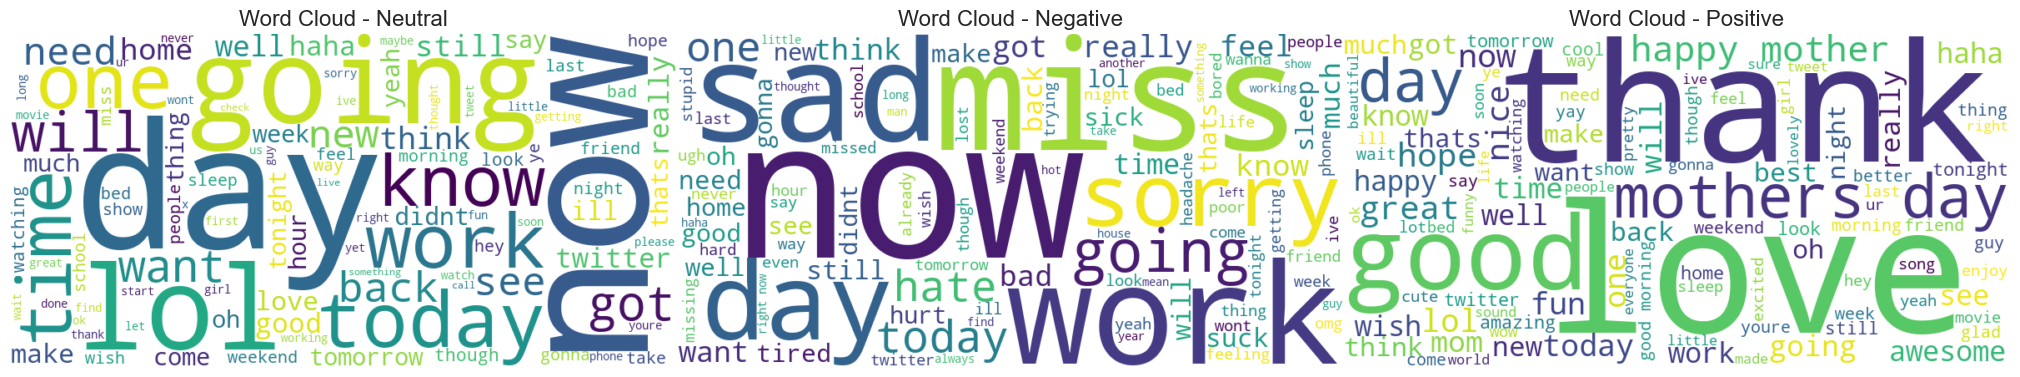

In [11]:
# Génération des Word Clouds

if df is not None:

    sentiments = df['sentiment'].unique()

    stopwords = set(STOPWORDS)

    # Ajouter des mots courants peu informatifs si besoin

    stopwords.update(["amp", "im", "go", "get", "dont", "u", "cant"])



    plt.figure(figsize=(20, 15))

    for i, sentiment in enumerate(sentiments):

        plt.subplot(1, len(sentiments), i + 1)

        subset = df[df['sentiment'] == sentiment]

        if not subset.empty:

            text = " ".join(review for review in subset['cleaned_text'] if isinstance(review, str))

            if text: # Vérifier si on a du texte après jointure

                 wordcloud = WordCloud(stopwords=stopwords, background_color="white", max_words=100, width=800, height=400).generate(text)

                 plt.imshow(wordcloud, interpolation='bilinear')

                 plt.title(f'Word Cloud - {sentiment.capitalize()}', fontsize=16)

            else:

                 plt.text(0.5, 0.5, 'Pas de texte à afficher', horizontalalignment='center', verticalalignment='center')

                 plt.title(f'Word Cloud - {sentiment.capitalize()} (Vide)', fontsize=16)



        else:

            plt.text(0.5, 0.5, 'Pas de données', horizontalalignment='center', verticalalignment='center')

            plt.title(f'Word Cloud - {sentiment.capitalize()} (Vide)', fontsize=16)

        plt.axis("off")



    plt.tight_layout(pad=0) # Ajuster le padding

    plt.show()

## Fin de l'Exploration


Ce notebook donne un premier aperçu des données. On voit une légère prédominance du sentiment neutre, des longueurs de texte variables, et le fait que `selected_text` est souvent identique au `text` complet, surtout pour les neutres. Les Word Clouds montrent des mots clés différents selon les sentiments.